# Experiment A — Budget-Constrained Input Design

Frank–Wolfe input design for a finite-horizon linear system under a covariance
budget. 

## System and generalized LQR tools

| Function or class | Purpose |
|---|---|
| `LinearSystem` | Stores $A$, $B$, process covariance, horizon, and initial covariance. |
| `symmetrize` | Projects a matrix onto the symmetric matrices. |
| `is_psd` | Numerically tests positive semidefiniteness. |
| `block_partition` | Splits a joint state–input matrix into its four blocks. |
| `generalized_lqr_riccati` | Solves the generalized finite-horizon Riccati recursion. |
| `induced_covariance` | Computes the joint policy covariance $\Sigma^\pi$ induced by a gain sequence. |

In [51]:
import numpy as np
from dataclasses import dataclass
from typing import List, Optional, Tuple


@dataclass
class LinearSystem:
    """Finite-horizon linear system x_{t+1} = A x_t + B u_t + w_t."""
    A: np.ndarray
    B: np.ndarray
    Sigma_w: np.ndarray
    H: int
    Sigma_x0: Optional[np.ndarray] = None


def symmetrize(M: np.ndarray) -> np.ndarray:
    """Project a matrix onto the symmetric matrices."""
    return 0.5 * (M + M.T)


def is_psd(M: np.ndarray, tol: float = 1e-9) -> bool:
    """Numerically test positive semidefiniteness."""
    eigs = np.linalg.eigvalsh(symmetrize(M))
    return np.min(eigs) >= -tol


def block_partition(
    M: np.ndarray, n: int
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Partition a stage-cost matrix M into xx/xu/ux/uu blocks,
    where the state has dimension n and the input has dimension m = M.shape[0] - n.
    """
    xx = M[:n, :n]
    xu = M[:n, n:]
    ux = M[n:, :n]
    uu = M[n:, n:]
    return xx, xu, ux, uu


def generalized_lqr_riccati(
    system: LinearSystem,
    M_tilde: np.ndarray,
    psd_tol: float = 1e-9,
) -> Tuple[bool, Optional[List[np.ndarray]], Optional[List[np.ndarray]], Optional[List[np.ndarray]]]:
    """
    Solve the finite-horizon generalized LQR problem with constant stage-cost
    matrix M_tilde = [[M_xx, M_xu], [M_ux, M_uu]].

    Returns
    -------
    well_posed : bool
        True if S_t is positive definite for all t.
    K_list : list[np.ndarray] or None
        Feedback gains u_t = -K_t x_t if well posed.
    P_list : list[np.ndarray] or None
        Riccati matrices.
    S_list : list[np.ndarray] or None
        S_t matrices in the recursion.
    """
    A, B, H = system.A, system.B, system.H
    n = A.shape[0]
    xx, xu, ux, uu = block_partition(M_tilde, n)

    P_list = [np.zeros((n, n)) for _ in range(H + 1)]  # terminal P_H = 0
    K_list = [np.zeros((B.shape[1], n)) for _ in range(H)]
    S_list = [np.zeros((B.shape[1], B.shape[1])) for _ in range(H)]

    for t in reversed(range(H)):
        P_next = P_list[t + 1]
        S_t = symmetrize(uu + B.T @ P_next @ B)
        S_list[t] = S_t

        
        if np.min(np.linalg.eigvalsh(S_t)) <= psd_tol:
            return False, None, None, None

        middle = ux + B.T @ P_next @ A
        S_inv = np.linalg.inv(S_t)  # robust near-singular inverse
        K_t = S_inv @ middle
        K_list[t] = K_t

        P_t = xx + A.T @ P_next @ A - middle.T @ K_t
        P_list[t] = symmetrize(P_t)

    return True, K_list, P_list, S_list


def induced_covariance(
    system: LinearSystem,
    K_list: List[np.ndarray],
) -> Tuple[np.ndarray, List[np.ndarray], List[np.ndarray], List[np.ndarray]]:
    """
    Propagate closed-loop covariances under u_t = -K_t x_t and return

        Sigma^pi = E[sum_t z_t z_t^T]

    together with per-time covariances Sigma_{x,t}, Sigma_{u,t}, Sigma_{xu,t}.
    """
    A, B, Sigma_w, H = system.A, system.B, system.Sigma_w, system.H
    n = A.shape[0]
    m = B.shape[1]
    Sigma_x = np.zeros((n, n)) if system.Sigma_x0 is None else system.Sigma_x0.copy()

    Sigma_pi = np.zeros((n + m, n + m))
    Sigma_x_list, Sigma_u_list, Sigma_xu_list = [], [], []

    for t in range(H):
        K_t = K_list[t]
        Sigma_u = K_t @ Sigma_x @ K_t.T
        Sigma_xu = -Sigma_x @ K_t.T

        Sigma_z = np.block([
            [Sigma_x, Sigma_xu],
            [Sigma_xu.T, Sigma_u],
        ])
        Sigma_pi += Sigma_z

        Sigma_x_list.append(Sigma_x.copy())
        Sigma_u_list.append(Sigma_u.copy())
        Sigma_xu_list.append(Sigma_xu.copy())

        A_cl = A - B @ K_t
        Sigma_x = symmetrize(A_cl @ Sigma_x @ A_cl.T + Sigma_w)

    return Sigma_pi, Sigma_x_list, Sigma_u_list, Sigma_xu_list




## Objective and Frank–Wolfe optimization

| Function | Purpose |
|---|---|
| `objective_value` | Evaluates $\operatorname{Tr}(W^{(1)}(\Sigma^\pi)^{-1})$. |
| `gradient_objective` | Computes the objective gradient with respect to $\Sigma^\pi$. |
| `solve_fixed_lambda_subproblem` | Solves one dual-regularized generalized LQR problem. |
| `bisection_lambda` | Uses a scale-aware bracket, folded bisection, and a minimum-energy fallback. |
| `frank_wolfe_input_design` | Runs FW updates and records covariances, policies, and dual values. |

In [52]:
def objective_value(Sigma_pi: np.ndarray, W_1: np.ndarray) -> float:
    """Evaluate f(Sigma^pi) = Tr(W^(1) (Sigma^pi)^{-1})."""
    Sigma_inv = np.linalg.pinv(symmetrize(Sigma_pi))
    return float(np.trace(W_1 @ Sigma_inv))


def gradient_objective(Sigma_pi: np.ndarray, W_1: np.ndarray) -> np.ndarray:
    """Evaluate ∇f(Sigma^pi) = -(Sigma^pi)^{-1} W^(1) (Sigma^pi)^{-1}."""
    
    Sigma_inv = np.linalg.inv(symmetrize(Sigma_pi))
    return -Sigma_inv @ W_1 @ Sigma_inv


def solve_fixed_lambda_subproblem(
    system: LinearSystem,
    M_i: np.ndarray,
    W_2: np.ndarray,
    lam: float,
    psd_tol: float = 1e-9,
) -> Tuple[bool, Optional[List[np.ndarray]], Optional[np.ndarray]]:
    """
    Solve the fixed-λ generalized LQR subproblem with stage-cost matrix

        M_tilde(λ) = M^(i) + λ W^(2).

    Returns whether it is well posed, the policy gains K_t, and Sigma^pi.
    """

    M_tilde = symmetrize(M_i + lam * W_2)
    well_posed, K_list, _, _ = generalized_lqr_riccati(system, M_tilde, psd_tol=psd_tol)
    if not well_posed:
        return False, None, None

    Sigma_pi, _, _, _ = induced_covariance(system, K_list)
    return True, K_list, Sigma_pi


def bisection_lambda(
    system: LinearSystem,
    beta: float,
    eps: float,
    lambda_min: float,
    lambda_max: float,
    J_max: int,
    M_i: np.ndarray,
    W_2: np.ndarray,
    psd_tol: float = 1e-10,
    max_expand_iters: Optional[int] = None,
) -> Tuple[float, List[np.ndarray], np.ndarray]:
    """Budget-constrained generalized LQR with a certified dual bracket.

    The public signature is unchanged. ``lambda_max`` is retained for backward
    compatibility; the actual upper endpoint is constructed from the
    minimum-energy value and expanded only as numerical safety.
    """
    if max_expand_iters is None:
        max_expand_iters = system.H

    
    ok_energy, K_energy, Sigma_energy = solve_fixed_lambda_subproblem(
        system=system, M_i=W_2, W_2=W_2, lam=0.0, psd_tol=psd_tol
    )
    if not ok_energy or K_energy is None or Sigma_energy is None:
        raise RuntimeError("Minimum-energy comparison policy is not well posed.")
    b0 = float(np.trace(W_2 @ Sigma_energy))
    if beta <= b0:
        return np.inf, K_energy, Sigma_energy

    # Exact zero-dual solution when it is admissible and already within budget.
    ok_zero, K_zero, Sigma_zero = solve_fixed_lambda_subproblem(
        system=system, M_i=M_i, W_2=W_2, lam=0.0, psd_tol=psd_tol
    )
    if ok_zero and K_zero is not None and Sigma_zero is not None:
        if float(np.trace(W_2 @ Sigma_zero)) <= beta:
            return 0.0, K_zero, Sigma_zero

    # Lemma-3(iv)-style scale-aware upper bracket.
    mu_W_2 = float(np.min(np.linalg.eigvalsh(W_2)))
    if mu_W_2 <= 0.0:
        raise ValueError("W_2 must be positive definite for the dual bracket.")
    max_M_norm = float(np.linalg.norm(symmetrize(M_i), ord=2))
    lam_hi = (beta + b0) / (beta - b0) * max_M_norm / mu_W_2
    lam_hi = max(lam_hi, 1e-8)

    K_best, Sigma_best = K_energy, Sigma_energy
    budget_best = b0
    found = False
    for _ in range(max(max_expand_iters, 80)):
        ok, K_try, Sigma_try = solve_fixed_lambda_subproblem(
            system=system, M_i=M_i, W_2=W_2, lam=lam_hi, psd_tol=psd_tol
        )
        if ok and K_try is not None and Sigma_try is not None:
            budget_try = float(np.trace(W_2 @ Sigma_try))
            if budget_try <= beta:
                K_best, Sigma_best = K_try, Sigma_try
                budget_best, found = budget_try, True
                break
        lam_hi *= 2.0

    # Safe fallback: never return an uninitialized or zero-gain sentinel.
    if not found:
        return np.inf, K_energy, Sigma_energy

    # folded bisection combines admissibility and budget feasibility.
    lam_lo = max(0.0, float(lambda_min))
    max_iters = min(max(int(J_max), 1), 200)
    for _ in range(max_iters):
        if lam_hi - lam_lo <= max(1e-12, 1e-8 * lam_hi):
            break
        lam_mid = 0.5 * (lam_lo + lam_hi)
        ok, K_mid, Sigma_mid = solve_fixed_lambda_subproblem(
            system=system, M_i=M_i, W_2=W_2, lam=lam_mid, psd_tol=psd_tol
        )
        if (not ok) or K_mid is None or Sigma_mid is None:
            lam_lo = lam_mid
            continue
        budget_mid = float(np.trace(W_2 @ Sigma_mid))
        if budget_mid > beta:
            lam_lo = lam_mid
        else:
            lam_hi = lam_mid
            K_best, Sigma_best, budget_best = K_mid, Sigma_mid, budget_mid
            # Certificate-style stop near the active budget boundary.
            if budget_best >= beta * (1.0 - 1e-8):
                break

    return lam_hi, K_best, Sigma_best


def frank_wolfe_input_design(
    system: LinearSystem,
    Sigma_initial: np.ndarray,
    W_1: np.ndarray,
    W_2: np.ndarray,
    beta: float,
    eps: float,
    lambda_max: float,
    J_max: int,
    I_max: int,
    max_expand_iters: Optional[int] = None,
):
    """
    Frank–Wolfe applied to

        min_pi Tr(W^(1) (Sigma^pi)^{-1})
        s.t.   Tr(W^(2) Sigma^pi) <= beta.

    Returns
    -------
    Sigma_iterates : list[np.ndarray]
        Frank–Wolfe iterates Sigma^{(i)}.
    objective_history : list[float]
        Objective values f(Sigma^{(i)}).
    policy_hist : list[list[np.ndarray]]
        Time-varying gains K_t for the policy returned by the LMO at each iteration.
    lambda_hist : list[float]
        Chosen λ values from the bisection solve.
    """
    Sigma_iterates = [symmetrize(Sigma_initial)]
    objective_history = [objective_value(Sigma_iterates[0], W_1)]
    policy_hist = []
    lambda_hist = []

    for i in range(I_max):
        Sigma_i = Sigma_iterates[-1]

        # Compute the Frank–Wolfe gradient
        M_i = gradient_objective(Sigma_i, W_1)

        # Linear minimization oracle via bisection over λ
        lam_star, policy_i, Sigma_pi = bisection_lambda(
            system=system,
            beta=beta,
            eps=eps,
            lambda_min=0.0,
            lambda_max=lambda_max,
            J_max=J_max,
            M_i=M_i,
            W_2=W_2,
            max_expand_iters=max_expand_iters,
        )

        fw_gap = abs(float(np.trace(M_i @ (Sigma_i - Sigma_pi))))
        policy_hist.append(policy_i)
        lambda_hist.append(lam_star)

        # Stopping criterion
        if fw_gap <= eps:
            break

        # Fixed step size
        alpha_i = 2.0 / (i + 2.0)

        # Frank–Wolfe update
        Sigma_next = symmetrize((1.0 - alpha_i) * Sigma_i + alpha_i * Sigma_pi)

        Sigma_iterates.append(Sigma_next)
        objective_history.append(objective_value(Sigma_next, W_1))

    return Sigma_iterates, objective_history, policy_hist, lambda_hist

## Optional Numba acceleration

The preceding functions are complete NumPy/SciPy implementations. This cell only
installs specialized fast paths when Numba is available; otherwise it preserves
the reference implementations.

| Accelerated routine | Purpose |
|---|---|
| `_solve_fixed_lambda_n2m1_numba` | Accelerates the repeated scalar-input Riccati and covariance calculation. |
| `solve_fixed_lambda_subproblem` | Selects the fast path when supported and otherwise calls the reference function. |


In [53]:
# ============================================================================
# Optional Numba acceleration
# ============================================================================
# The NumPy/SciPy implementations above are the reference implementations.
# If Numba is installed, this cell installs specialized fast paths for the
# experiment's 2-state/1-input system. Otherwise, the reference code is used.

try:
    import numba as nb
    _NUMBA_AVAILABLE = True
except Exception:
    nb = None
    _NUMBA_AVAILABLE = False

_solve_fixed_lambda_numpy_reference = solve_fixed_lambda_subproblem

if _NUMBA_AVAILABLE:
    @nb.njit
    def _solve_fixed_lambda_n2m1_numba(
        A, B, M_i, W_2, lam, Sigma_w, horizon, Sigma_x0, pd_tol
    ):
        """Combined Riccati and covariance kernel for the experiment's 2x1 system."""
        M = 0.5 * (M_i + lam * W_2 + (M_i + lam * W_2).T)
        K = np.zeros((horizon, 1, 2), dtype=np.float64)
        P = np.zeros((2, 2), dtype=np.float64)
        b0 = B[0, 0]
        b1 = B[1, 0]

        for t in range(horizon - 1, -1, -1):
            pb0 = P[0, 0] * b0 + P[0, 1] * b1
            pb1 = P[1, 0] * b0 + P[1, 1] * b1
            control_hessian = M[2, 2] + b0 * pb0 + b1 * pb1
            if control_hessian <= pd_tol:
                return False, K, np.zeros((3, 3), dtype=np.float64)

            r0 = (M[2, 0] + b0 * (P[0, 0] * A[0, 0] + P[0, 1] * A[1, 0])
                  + b1 * (P[1, 0] * A[0, 0] + P[1, 1] * A[1, 0]))
            r1 = (M[2, 1] + b0 * (P[0, 0] * A[0, 1] + P[0, 1] * A[1, 1])
                  + b1 * (P[1, 0] * A[0, 1] + P[1, 1] * A[1, 1]))
            K[t, 0, 0] = r0 / control_hessian
            K[t, 0, 1] = r1 / control_hessian

            AP00 = A[0, 0] * P[0, 0] + A[1, 0] * P[1, 0]
            AP01 = A[0, 0] * P[0, 1] + A[1, 0] * P[1, 1]
            AP10 = A[0, 1] * P[0, 0] + A[1, 1] * P[1, 0]
            AP11 = A[0, 1] * P[0, 1] + A[1, 1] * P[1, 1]
            ata00 = AP00 * A[0, 0] + AP01 * A[1, 0]
            ata01 = AP00 * A[0, 1] + AP01 * A[1, 1]
            ata11 = AP10 * A[0, 1] + AP11 * A[1, 1]
            P[0, 0] = M[0, 0] + ata00 - r0 * r0 / control_hessian
            P[0, 1] = M[0, 1] + ata01 - r0 * r1 / control_hessian
            P[1, 0] = P[0, 1]
            P[1, 1] = M[1, 1] + ata11 - r1 * r1 / control_hessian

        Sx = Sigma_x0.copy()
        total = np.zeros((3, 3), dtype=np.float64)
        for t in range(horizon):
            k0 = K[t, 0, 0]
            k1 = K[t, 0, 1]
            xu0 = -(Sx[0, 0] * k0 + Sx[0, 1] * k1)
            xu1 = -(Sx[1, 0] * k0 + Sx[1, 1] * k1)
            uu = k0 * (Sx[0, 0] * k0 + Sx[0, 1] * k1) + k1 * (
                Sx[1, 0] * k0 + Sx[1, 1] * k1
            )
            total[0, 0] += Sx[0, 0]; total[0, 1] += Sx[0, 1]
            total[1, 0] += Sx[1, 0]; total[1, 1] += Sx[1, 1]
            total[0, 2] += xu0; total[2, 0] += xu0
            total[1, 2] += xu1; total[2, 1] += xu1
            total[2, 2] += uu

            f00 = A[0, 0] - B[0, 0] * k0; f01 = A[0, 1] - B[0, 0] * k1
            f10 = A[1, 0] - B[1, 0] * k0; f11 = A[1, 1] - B[1, 0] * k1
            n00 = f00 * (Sx[0, 0] * f00 + Sx[0, 1] * f01) + f01 * (
                Sx[1, 0] * f00 + Sx[1, 1] * f01
            ) + Sigma_w[0, 0]
            n01 = f00 * (Sx[0, 0] * f10 + Sx[0, 1] * f11) + f01 * (
                Sx[1, 0] * f10 + Sx[1, 1] * f11
            ) + Sigma_w[0, 1]
            n11 = f10 * (Sx[0, 0] * f10 + Sx[0, 1] * f11) + f11 * (
                Sx[1, 0] * f10 + Sx[1, 1] * f11
            ) + Sigma_w[1, 1]
            Sx[0, 0] = n00; Sx[0, 1] = n01; Sx[1, 0] = n01; Sx[1, 1] = n11
        return True, K, total


def solve_fixed_lambda_subproblem(
    system: LinearSystem,
    M_i: np.ndarray,
    W_2: np.ndarray,
    lam: float,
    psd_tol: float = 1e-9,
) -> Tuple[bool, Optional[List[np.ndarray]], Optional[np.ndarray]]:
    """
    Solve the fixed-λ generalized LQR subproblem with stage-cost matrix

        M_tilde(λ) = M^(i) + λ W^(2).

    Returns whether it is well posed, the policy gains K_t, and Sigma^pi.
    """
    # FAST A1: specialize the repeated 2-state/1-input oracle evaluation.
    if _NUMBA_AVAILABLE and system.A.shape == (2, 2) and system.B.shape == (2, 1):
        Sigma_x0 = (np.zeros((2, 2)) if system.Sigma_x0 is None
                    else np.asarray(system.Sigma_x0, dtype=float))
        well_posed, K_array, Sigma_pi = _solve_fixed_lambda_n2m1_numba(
            np.ascontiguousarray(system.A, dtype=float),
            np.ascontiguousarray(system.B, dtype=float),
            np.ascontiguousarray(M_i, dtype=float),
            np.ascontiguousarray(W_2, dtype=float),
            float(lam), np.ascontiguousarray(system.Sigma_w, dtype=float),
            int(system.H), np.ascontiguousarray(Sigma_x0), float(psd_tol),
        )
        if not well_posed:
            return False, None, None
        return True, [K_array[t].copy() for t in range(system.H)], Sigma_pi

    return _solve_fixed_lambda_numpy_reference(
        system=system, M_i=M_i, W_2=W_2, lam=lam, psd_tol=psd_tol
    )


print(
    "Numba fast path installed." if _NUMBA_AVAILABLE
    else "Numba unavailable; using the NumPy reference implementation."
)


Numba fast path installed.


## Main experiment

| Block | Purpose |
|---|---|
| Problem setup | Defines the system, objective weights, and feasible initial covariance. |
| Budget sweep | Runs FW for several values of $\beta$. |
| Output | Plots objective histories and exports `fw_objective_vs_beta.tex`. |

Executing this cell runs the complete experiment.

Initial feasible budget use: 16.450845
beta=20.00 | iterations=51 | initial obj=12.715837 | final obj=0.437563 | final budget use=20.000000
beta=50.00 | iterations=51 | initial obj=12.715837 | final obj=0.157500 | final budget use=49.999914
beta=100.00 | iterations=51 | initial obj=12.715837 | final obj=0.079947 | final budget use=99.999618
beta=200.00 | iterations=51 | initial obj=12.715837 | final obj=0.040537 | final budget use=199.996436
beta=500.00 | iterations=51 | initial obj=12.715837 | final obj=0.016405 | final budget use=499.884670
beta=1000.00 | iterations=51 | initial obj=12.715837 | final obj=0.008265 | final budget use=996.253794


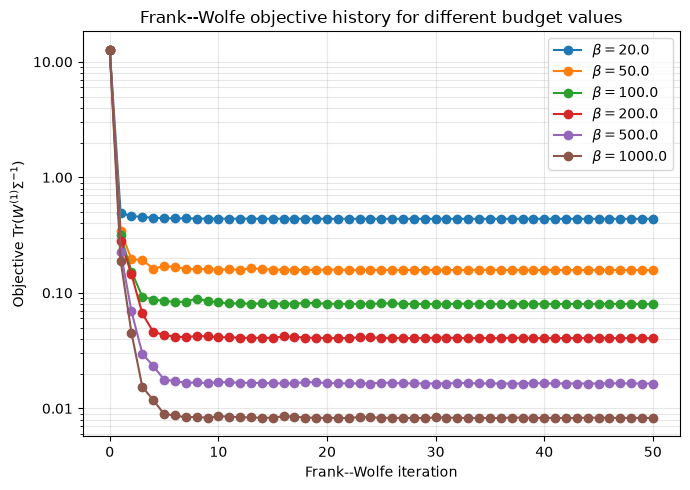

In [54]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import tikzplotlib

    # User-chosen problem data
    H = 100
    A = np.array([
        [1.0, 0.15],
        [0.0, 0.92],
    ])
    B = np.array([
        [0.1],
        [0.4],
    ])
    Sigma_w = 0.02 * np.eye(2)

    system = LinearSystem(
        A=A,
        B=B,
        Sigma_w=Sigma_w,
        H=H,
    )

    n, m = A.shape[0], B.shape[1]

    # Weight matrices in the objective and budget constraint
    W_1 = np.diag([2.0, 1.0, 0.5])
    W_2 = np.diag([1.0, 1.0, 0.3])

    # Construct an initial feasible covariance
    M_init = np.zeros((n + m, n + m))
    # Maybe initial prior should be selected differently
    ok, _, Sigma_initial = solve_fixed_lambda_subproblem(
        system=system,
        M_i=M_init,
        W_2=W_2,
        lam=1.0,
    )
    if not ok or Sigma_initial is None:
        raise RuntimeError("Failed to construct a feasible initial covariance.")

    initial_budget_use = float(np.trace(W_2 @ Sigma_initial))
    print(f"Initial feasible budget use: {initial_budget_use:.6f}")

    # Grid of budget values
    beta_grid = [20.0, 50.0, 100.0,200.0, 500.0, 1000.0]

    # Frank–Wolfe / bisection parameters
    eps = 1e-10
    lambda_max = 1000
    J_max = 5000
    I_max = 50

    # Run Frank–Wolfe for each beta
    results = {}

    for beta in beta_grid:
        Sigma_iterates, objective_history, policy_hist, lambda_hist = frank_wolfe_input_design(
            system=system,
            Sigma_initial=Sigma_initial,
            W_1=W_1,
            W_2=W_2,
            beta=beta,
            eps=eps,
            lambda_max=lambda_max,
            J_max=J_max,
            I_max=I_max,
            max_expand_iters=H,
        )

        results[beta] = {
            "Sigma_iterates": Sigma_iterates,
            "objective_history": objective_history,
            "policy_hist": policy_hist,
            "lambda_hist": lambda_hist,
        }

        print(
            f"beta={beta:.2f} | "
            f"iterations={len(objective_history)} | "
            f"initial obj={objective_history[0]:.6f} | "
            f"final obj={objective_history[-1]:.6f} | "
            f"final budget use={np.trace(W_2 @ Sigma_iterates[-1]):.6f}"
        )

    # Plot objective histories for all beta values on a log scale
    plt.figure(figsize=(7, 5))
    for beta in beta_grid:
        objective_history = results[beta]["objective_history"]
        iters = np.arange(len(objective_history))
        plt.semilogy(iters, objective_history, marker="o", label=fr"$\beta={beta}$")

    plt.xlabel("Frank--Wolfe iteration")
    plt.ylabel(r"Objective $\mathrm{Tr}(W^{(1)} \Sigma^{-1})$")
    plt.title("Frank--Wolfe objective history for different budget values")
    plt.grid(True, which="both", alpha=0.3)

    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    plt.legend(loc="upper right")
    plt.tight_layout()


    # Save as TikZ/PGFPlots
    tikzplotlib.save("fw_objective_vs_beta.tex")

    plt.show()